In [1]:
import ast
from typing import Dict, Tuple
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. טעינת הקבצים הגולמיים מהמחשב
df_raw = pd.read_csv('dataset.csv', encoding='utf-8')

# 2. טעינת טבלת הקישור של הבמאים (במלואה, ללא סינונים מקדימים)
print("Loading crew lookup table...")
crew_lookup_df = pd.read_csv(
    'title.crew.tsv', 
    sep='\t', 
    usecols=['tconst', 'directors'], 
    na_values='\\N'
)
print(f"Files loaded! Raw movies: {len(df_raw)}, Crew rows: {len(crew_lookup_df)}")

C:\Users\micha\AppData\Local\Temp\ipykernel_5212\1977598949.py:12: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('dataset.csv', encoding='utf-8')


Loading crew lookup table...
Files loaded! Raw movies: 133884, Crew rows: 12522499


In [ ]:
def clean_data(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    חלק 1: פונקציית ניקוי ובדיקת תקינות ראשונית של הדאטה הגולמי.
    מנקה שורות פגומות קשות ומסננת לפי אורך לסרטים בלבד.
    """
    print("--- Running clean_data pipeline ---")
    data = raw_df.copy()
    
    # א. הסרת שורות חסרות במזהה, שנה, או משתנה המטרה (averageRating)
    data = data.dropna(subset=['tconst', 'startYear', 'averageRating'])
    
    # ב. המרת טיפוסים רשמית
    data['startYear'] = pd.to_numeric(data['startYear'], errors='coerce')
    data['averageRating'] = pd.to_numeric(data['averageRating'], errors='coerce')
    data['runtimeMinutes'] = pd.to_numeric(data['runtimeMinutes'], errors='coerce')
    
    valid_runtime = (data['runtimeMinutes'].isna()) | ((data['runtimeMinutes'] >= 60) & (data['runtimeMinutes'] <= 300))
    data = data[valid_runtime].copy()
    
    # ד. הסרת עמודות שאסור להשתמש בהן
    cols_to_drop = ['BoxOffice', 'budget', 'numVotes', 'Unnamed: 0', 'writers', 'originalTitle']
    data.drop(columns=[c for c in cols_to_drop if c in data.columns], errors='ignore', inplace=True)
    
    print(f"-> clean_data finished! Rows remaining: {len(data)}\n")
    return data

# הרצת הניקוי לקבלת הדאטה הסטרילי אצלך במחשב
df_cleaned = clean_data(df_raw)

--- Running clean_data pipeline ---
-> clean_data finished! Rows remaining: 115560



In [ ]:
def prepare_data(df: pd.DataFrame, crew_lookup_df: pd.DataFrame = None, is_train: bool = False, mappings: dict = None) -> pd.DataFrame:
    """
    פונקציית העל הרשמית והיחידה של חלק 3.1.
    מקבלת DataFrame ומחזירה DataFrame מעובד ומוכן למודלים, ללא זליגת נתונים.
    """
    X = df.copy()
    
    # מנגנון הגנה אוטומטי לטסט החיצוני של חן
    if crew_lookup_df is None:
        crew_lookup_df = globals().get('crew_lookup_df', pd.DataFrame(columns=['tconst', 'directors']))
    if mappings is None:
        mappings = globals().get('trained_mappings', {})

    # שליפת משתנה המטרה והסרתו מהמטריצה
    y_input = X['averageRating'].copy() if 'averageRating' in X.columns else None
    X.drop(columns=['averageRating', 'BoxOffice', 'budget', 'numVotes', 'Unnamed: 0', 'writers', 'originalTitle'], errors='ignore', inplace=True)
    
    if 'startYear' in X.columns:
        X['startYear'] = pd.to_numeric(X['startYear'], errors='coerce').fillna(2000)

    # -----------------------------------------------------------------
    # פיצ'ר 1: מוניטין שחקנים 
    # -----------------------------------------------------------------
    def parse_actor_list(val) -> list:
        if pd.isna(val) or val is None: return []
        if isinstance(val, list): return val
        if isinstance(val, str):
            val_cleaned = val.strip()
            if val_cleaned.startswith('[') and val_cleaned.endswith(']'):
                try: return ast.literal_eval(val_cleaned)
                except (ValueError, SyntaxError):
                    val_cleaned = val_cleaned.strip('[]').replace("'", "").replace('"', "")
                    return [actor.strip() for actor in val_cleaned.split(',') if actor.strip()]
            if val_cleaned: return [actor.strip() for actor in val_cleaned.split(',') if actor.strip()]
        return []

    actor_col = 'lead_actors_ids' if 'lead_actors_ids' in X.columns else 'cast'
    X['cleaned_actor_list'] = X[actor_col].apply(parse_actor_list) if actor_col in X.columns else [[] for _ in range(len(X))]
    
    if is_train and y_input is not None:
        actor_history = {}
        df_temp = X.copy()
        df_temp['target_rating'] = y_input
        df_exploded = df_temp.explode('cleaned_actor_list').dropna(subset=['cleaned_actor_list', 'startYear', 'target_rating'])
        
        for _, row in df_exploded.iterrows():
            actor = row['cleaned_actor_list']
            if actor not in actor_history: actor_history[actor] = []
            actor_history[actor].append((int(row['startYear']), float(row['target_rating'])))
            
        mappings['actor'] = {'scores': actor_history, 'global_mean': float(y_input.mean())}

    actor_repo = mappings.get('actor', {'scores': {}, 'global_mean': 5.5})
    
    def calculate_weighted_actor_score(row):
        actors = row['cleaned_actor_list']
        movie_year = row['startYear']
        if not actors or pd.isna(movie_year): return actor_repo['global_mean']
        
        min_year, max_year = int(movie_year) - 10, int(movie_year) - 1
        actor_scores = []
        
        for actor in actors:
            history = actor_repo['scores'].get(actor, [])
            relevant_ratings = [rating for year, rating in history if min_year <= year <= max_year]
            actor_scores.append(np.mean(relevant_ratings) if relevant_ratings else None)
            
        known_scores = [score for score in actor_scores if score is not None]
        if known_scores:
            N = len(known_scores)
            weights = [N - i for i in range(N)]
            return np.average(known_scores, weights=weights)
        return actor_repo['global_mean']

    X['weighted_actor_reputation_10yrs'] = X.apply(calculate_weighted_actor_score, axis=1)
    X.drop(columns=['cleaned_actor_list'], inplace=True, errors='ignore')

    # -----------------------------------------------------------------
    # פיצ'ר 2: מוניטין במאים 
    # -----------------------------------------------------------------
    X = pd.merge(X, crew_lookup_df[['tconst', 'directors']], on='tconst', how='left')
    
    def _get_director_list(val):
        if pd.isna(val): return []
        return [d.strip() for d in str(val).split(',') if d.strip()]
        
    X['director_ids_list'] = X['directors'].apply(_get_director_list)
    X['year_numeric'] = pd.to_numeric(X['startYear'], errors='coerce')

    if is_train and y_input is not None:
        director_repo_dict = {}
        df_temp = X[['director_ids_list', 'year_numeric']].copy()
        df_temp['target_rating'] = y_input.values
        df_exploded = df_temp.explode('director_ids_list').dropna(subset=['director_ids_list'])
        
        for director_id, group in df_exploded.groupby('director_ids_list'):
            director_repo_dict[director_id] = group[['year_numeric', 'target_rating']].to_dict(orient='records')
            
        director_repo_dict['GLOBAL_DEFAULT'] = float(y_input.mean())
        mappings['director'] = director_repo_dict

    director_repo = mappings.get('director', {'GLOBAL_DEFAULT': 5.5})
    global_default = director_repo.get('GLOBAL_DEFAULT', 5.5)
    movie_scores = []
    
    for _, row in X.iterrows():
        current_year = row['year_numeric']
        directors_in_movie = row['director_ids_list']
        if not directors_in_movie or pd.isna(current_year):
            movie_scores.append(global_default)
            continue
            
        current_directors_scores = []
        for d_id in directors_in_movie:
            if d_id in director_repo:
                past_movies = [m['target_rating'] for m in director_repo[d_id] if (current_year - 10) <= m['year_numeric'] < current_year]
                if past_movies: current_directors_scores.append(np.mean(past_movies))
                
        movie_scores.append(np.mean(current_directors_scores) if current_directors_scores else global_default)
        
    X['weighted_director_reputation_10yrs'] = movie_scores
    X.drop(columns=['directors', 'director_ids_list', 'year_numeric'], inplace=True, errors='ignore')

    # ----------------------
    # פיצ'ר 3: אורך הסרט 
    # -----------------------
    if is_train:
        mappings['runtime'] = {'median_value': X['runtimeMinutes'].median() if X['runtimeMinutes'].notna().any() else 90.0}
    
    runtimes = pd.to_numeric(X['runtimeMinutes'], errors='coerce').fillna(mappings.get('runtime', {}).get('median_value', 90.0))
    X['runtime_short'] = runtimes.apply(lambda x: 1 if 60 <= x <= 90 else 0)
    X['runtime_medium'] = runtimes.apply(lambda x: 1 if 90 < x <= 140 else 0)
    X['runtime_long'] = runtimes.apply(lambda x: 1 if 140 < x <= 300 else 0)

    # -----------------
    # פיצ'ר 4: ז'אנרים 
    # --------------------
    def _clean_genres_to_list(val):
        if pd.isna(val) or val is None: return []
        return [cleaned_g for g in str(val).split(',') if (cleaned_g := g.strip().replace('[', '').replace(']', '').replace("'", "").replace('"', ""))]

    X['cleaned_genre_list'] = X['genres'].apply(_clean_genres_to_list)
    
    if is_train:
        all_genres = [g for row in X['cleaned_genre_list'] for g in row]
        mappings['genre'] = {'top_genres': pd.Series(all_genres).value_counts().nlargest(11).index.tolist()}
        
    top_genres_list = mappings.get('genre', {}).get('top_genres', [])
    X['genre_missing'] = X['cleaned_genre_list'].apply(lambda x: 1 if len(x) == 0 else 0)
    
    for genre in top_genres_list:
        X[f'genre_{genre.lower()}'] = X['cleaned_genre_list'].apply(lambda x: 1 if genre in x else 0)
        
    X['genre_other'] = X['cleaned_genre_list'].apply(lambda x: 1 if len(x) > 0 and not any(g in top_genres_list for g in x) else 0)
    X.drop(columns=['cleaned_genre_list'], inplace=True, errors='ignore')

    # -----------------------------------------------------------------
    # העמודה החדשה: תיעוד שפה לא ידועה/חסרה)
    # -----------------------------------------------------------------
    def check_language_status(row):
        lang = str(row.get('Language', '')).lower().strip()
        # אם השפה חסרה או מסומנת כלא ידועה
        if pd.isna(row.get('Language')) or lang in ['nan', 'unknown', '']:
            return 1, 0  # unknown=1, is_english=0
        
        is_eng = 1 if 'english' in lang else 0
        return 0, is_eng  # unknown=0, לפי הבדיקה

    status_results = X.apply(check_language_status, axis=1)
    X['is_language_unknown'] = [res[0] for res in status_results]
    X['is_english_language'] = [res[1] for res in status_results]

    if is_train:
        globals()['trained_mappings'] = mappings

    # -----------------------------------------------------------------
    # שלב ג: יישור עמודות קשיח לחלוטין )
    # -----------------------------------------------------------------
    final_cols_order = [f'genre_{g.lower()}' for g in top_genres_list] + \
                       ['genre_missing', 'genre_other', 'runtime_short', 'runtime_medium', 'runtime_long', \
                        'weighted_actor_reputation_10yrs', 'weighted_director_reputation_10yrs', \
                        'is_english_language', 'is_language_unknown']
                       
    X_final = X.reindex(columns=final_cols_order, fill_value=0.0).fillna(0.0)
    return X_final

In [4]:
print("Splitting data into Train and Test sets...")
# פיצול 70/30 חוקי על בסיס ה-df_cleaned הנקי
X_train_raw, X_test_raw = train_test_split(df_cleaned, test_size=0.3, random_state=42)

y_train_raw = X_train_raw['averageRating'].copy()
y_test_raw = X_test_raw['averageRating'].copy()

print(f"Data split successfully! Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

Splitting data into Train and Test sets...
Data split successfully! Train shape: (80892, 10), Test shape: (34668, 10)


In [5]:
def run_random_forest_pipeline(X_train: pd.DataFrame, y_train: pd.Series):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    r2_scores, rmse_scores, mae_scores = [], [], []
    
    print("Starting Official 10-Fold Cross-Validation for Random Forest...\n")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train), 1):
        X_tr, X_val = X_train.iloc[train_idx].copy(), X_train.iloc[val_idx].copy()
        
        fold_mappings = {}
        X_tr_final = prepare_data(X_tr, crew_lookup_df, is_train=True, mappings=fold_mappings)
        X_val_final = prepare_data(X_val, crew_lookup_df, is_train=False, mappings=fold_mappings)
        
        model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
        model.fit(X_tr_final, y_train.iloc[train_idx])
        predictions = model.predict(X_val_final)
        
        r2_scores.append(r2_score(y_train.iloc[val_idx], predictions))
        rmse_scores.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], predictions)))
        mae_scores.append(mean_absolute_error(y_train.iloc[val_idx], predictions))
        
        print(f"Fold {fold}: R² = {r2_scores[-1]:.4f}, RMSE = {rmse_scores[-1]:.4f}, MAE = {mae_scores[-1]:.4f}")
        
    print("\n=== RANDOM FOREST FINAL 10-FOLD RESULTS ===")
    print(f"• R² Score:   Mean = {np.mean(r2_scores):.4f} (+/- Std = {np.std(r2_scores):.4f})")
    print(f"• RMSE Score: Mean = {np.mean(rmse_scores):.4f} (+/- Std = {np.std(rmse_scores):.4f})")
    print(f"• MAE Score:  Mean = {np.mean(mae_scores):.4f} (+/- Std = {np.std(mae_scores):.4f})\n")

def run_elastic_net_pipeline(X_train: pd.DataFrame, y_train: pd.Series):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    r2_scores, rmse_scores, mae_scores = [], [], []
    
    print("Starting Official 10-Fold Cross-Validation for Elastic Net...\n")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train), 1):
        X_tr, X_val = X_train.iloc[train_idx].copy(), X_train.iloc[val_idx].copy()
        
        fold_mappings = {}
        X_tr_final = prepare_data(X_tr, crew_lookup_df, is_train=True, mappings=fold_mappings)
        X_val_final = prepare_data(X_val, crew_lookup_df, is_train=False, mappings=fold_mappings)
        
        # Scaling לרציפים בלבד בתוך ה-Fold למניעת Data Leakage
        continuous_cols = ['weighted_actor_reputation_10yrs', 'weighted_director_reputation_10yrs']
        scaler = StandardScaler()
        
        X_tr_scaled = X_tr_final.copy()
        X_val_scaled = X_val_final.copy()
        
        X_tr_scaled[continuous_cols] = scaler.fit_transform(X_tr_final[continuous_cols])
        X_val_scaled[continuous_cols] = scaler.transform(X_val_final[continuous_cols])
        
        model = ElasticNet(alpha=0.001, l1_ratio=0.3, random_state=42, max_iter=2000)
        model.fit(X_tr_scaled, y_train.iloc[train_idx])
        predictions = model.predict(X_val_scaled)
        
        r2_scores.append(r2_score(y_train.iloc[val_idx], predictions))
        rmse_scores.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], predictions)))
        mae_scores.append(mean_absolute_error(y_train.iloc[val_idx], predictions))
        
        print(f"Fold {fold}: R² = {r2_scores[-1]:.4f}, RMSE = {rmse_scores[-1]:.4f}, MAE = {mae_scores[-1]:.4f}")
        
    print("\n=== ELASTIC NET FINAL 10-FOLD RESULTS ===")
    print(f"• R² Score:   Mean = {np.mean(r2_scores):.4f} (+/- Std = {np.std(r2_scores):.4f})")
    print(f"• RMSE Score: Mean = {np.mean(rmse_scores):.4f} (+/- Std = {np.std(rmse_scores):.4f})")
    print(f"• MAE Score:  Mean = {np.mean(mae_scores):.4f} (+/- Std = {np.std(mae_scores):.4f})\n")

# פקודת ההרצה הסופית
run_random_forest_pipeline(X_train_raw, y_train_raw)
run_elastic_net_pipeline(X_train_raw, y_train_raw)

Starting Official 10-Fold Cross-Validation for Random Forest...



Fold 1: R² = 0.3121, RMSE = 1.0770, MAE = 0.8221
Fold 2: R² = 0.3151, RMSE = 1.0828, MAE = 0.8255
Fold 3: R² = 0.3182, RMSE = 1.0591, MAE = 0.7980
Fold 4: R² = 0.2892, RMSE = 1.0961, MAE = 0.8249
Fold 5: R² = 0.2977, RMSE = 1.0791, MAE = 0.8170
Fold 6: R² = 0.3157, RMSE = 1.0924, MAE = 0.8274
Fold 7: R² = 0.3347, RMSE = 1.0553, MAE = 0.8010
Fold 8: R² = 0.3127, RMSE = 1.0577, MAE = 0.8031
Fold 9: R² = 0.3041, RMSE = 1.0719, MAE = 0.8116
Fold 10: R² = 0.3213, RMSE = 1.0642, MAE = 0.8085

=== RANDOM FOREST FINAL 10-FOLD RESULTS ===
• R² Score:   Mean = 0.3121 (+/- Std = 0.0121)
• RMSE Score: Mean = 1.0736 (+/- Std = 0.0137)
• MAE Score:  Mean = 0.8139 (+/- Std = 0.0104)

Starting Official 10-Fold Cross-Validation for Elastic Net...

Fold 1: R² = 0.2986, RMSE = 1.0874, MAE = 0.8338
Fold 2: R² = 0.3063, RMSE = 1.0897, MAE = 0.8349
Fold 3: R² = 0.3035, RMSE = 1.0705, MAE = 0.8083
Fold 4: R² = 0.2784, RMSE = 1.1044, MAE = 0.8365
Fold 5: R² = 0.2900, RMSE = 1.0849, MAE = 0.8221
Fold 6: R² = 0

In [6]:
print("=== Running Final Evaluation on the Static Test Set (Official Structured) ===")

# 1. יצירת מילון mappings ריק שישמור את מה שהפונקציה לומדת מה-Train
final_trained_mappings = {}

# 2. הרצת ה-Train המלא ב-prepare_data במצב אימון (למידת המילונים, חציונים וז'אנרים)
X_train_final_model = prepare_data(X_train_raw, crew_lookup_df, is_train=True, mappings=final_trained_mappings)

# 3. הרצת ה-Test המלא ב-prepare_data במצב ריצה (שימוש במילונים שנלמדו מה-Train - מניעת זליגה!)
X_test_final_model = prepare_data(X_test_raw, crew_lookup_df, is_train=False, mappings=final_trained_mappings)

# 4. וידוא הגדרת משתני המטרה (y) מהפיצול המקורי
y_train_final = y_train_raw.values
y_test_final = y_test_raw.values

# 5. הגדרת ואימון המודל המנצח (Random Forest) על כל ה-Train המעובד והסופי
final_rf_model = RandomForestRegressor(
    n_estimators=200, 
    max_depth=10, 
    min_samples_split=5, 
    random_state=42, 
    n_jobs=-1
)
final_rf_model.fit(X_train_final_model, y_train_final)

# 6. ביצוע החיזוי הסופי על ה-Test Set הסגור
final_test_predictions = final_rf_model.predict(X_test_final_model)

# 7. חישוב מדדי ההערכה הסופיים הרשמיים והסופיים של הפרויקט
final_r2 = r2_score(y_test_final, final_test_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test_final, final_test_predictions))
final_mae = mean_absolute_error(y_test_final, final_test_predictions)

print("\n=======================================================")
print(f" OFFICIAL PROJECT FINAL PERFORMANCE ON TEST SET:")
print(f" • R² Score (Explanation of Variance): {final_r2:.4f}")
print(f" • RMSE Score (Standard Deviation of Error): {final_rmse:.4f}")
print(f" • MAE Score (Mean Absolute Error): {final_mae:.4f}")
print("=======================================================")

=== Running Final Evaluation on the Static Test Set (Official Structured) ===

 OFFICIAL PROJECT FINAL PERFORMANCE ON TEST SET:
 • R² Score (Explanation of Variance): 0.3095
 • RMSE Score (Standard Deviation of Error): 1.0709
 • MAE Score (Mean Absolute Error): 0.8097


In [7]:
print("=== Running Error Analysis: Top 10 Overestimations & Underestimations ===")

# 1. הפקת הפיצ'רים על ה-Train וה-Test המלאים (באמצעות הצינור הרשמי)
final_mappings = {}
X_train_final = prepare_data(X_train_raw, crew_lookup_df, is_train=True, mappings=final_mappings)
X_test_final = prepare_data(X_test_raw, crew_lookup_df, is_train=False, mappings=final_mappings)

# 2. אימון מודל ה-Random Forest הסופי
rf_analyst = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
rf_analyst.fit(X_train_final, y_train_raw)

# 3. ביצוע חיזוי על ה-Test set (עליו אנחנו מנתחים שגיאות)
test_preds = rf_analyst.predict(X_test_final)

# 4. יצירת טבלת ניתוח שגיאות שמחברת את שמות הסרטים המקוריים עם התחזיות
error_df = X_test_raw.copy()
error_df['Actual_Rating'] = y_test_raw.values
error_df['Predicted_Rating'] = test_preds

# חישוב השארית (Error / Residual): מציאות פחות תחזית
# ערך חיובי גדול = המציאות גבוהה בהרבה מהתחזית (הערכת חסר של המודל)
# ערך שלילי גדול = התחזית גבוהה בהרבה מהמציאות (הערכת יתר של המודל)
error_df['Residual'] = error_df['Actual_Rating'] - error_df['Predicted_Rating']
error_df['Absolute_Error'] = error_df['Residual'].abs()

# עמודות שנעים לראות בעיניים כדי להבין איזה סרט זה
display_cols = ['tconst', 'primaryTitle', 'startYear', 'genres', 'Actual_Rating', 'Predicted_Rating', 'Residual']

# 5. שליפת 10 הסרטים עם הערכת היתר הכי קשה (המודל נתן ציון גבוה מדי, ריסרצ' שלילי ענק)
print("\n🥇 TOP 10 OVERESTIMATIONS (המודל חזה ציון גבוה מדי בהרבה מהמציאות):")
top_10_over = error_df.sort_values(by='Residual', ascending=True).head(10)
display(top_10_over[display_cols])

# 6. שליפת 10 הסרטים עם הערכת החסר הכי קשה (המודל נתן ציון נמוך מדי, ריסרצ' חיובי ענק)
print("\n🥈 TOP 10 UNDERESTIMATIONS (המודל חזה ציון נמוך מדי בהרבה מהמציאות):")
top_10_under = error_df.sort_values(by='Residual', ascending=False).head(10)
display(top_10_under[display_cols])

=== Running Error Analysis: Top 10 Overestimations & Underestimations ===

🥇 TOP 10 OVERESTIMATIONS (המודל חזה ציון גבוה מדי בהרבה מהמציאות):


,tconst,primaryTitle,startYear,genres,Actual_Rating,Predicted_Rating,Residual
133563,tt13452818,Horseplay: The History of Horse Riding,2021.0,"Animation,Documentary",1.0,7.170281,-6.170281
12464,tt3059576,Justin Bieber: Always Believing,2012.0,"Documentary,Music",1.0,7.170281,-6.170281
52638,tt2124890,Ramo Trip,2012.0,['Documentary'],1.4,7.278123,-5.878123
104680,tt1537218,Brush with Life: The Art of Being Edward Biberman,2007.0,['Documentary'],1.5,7.170281,-5.670281
52582,tt0808438,Rape of the Soul,2006.0,"['Documentary', 'History']",1.7,7.278123,-5.578123
84069,tt0498734,Zwischen Glück und Krone,1959.0,['Documentary'],1.2,6.734668,-5.534668
31588,tt2370036,On BorrowedTime,2012.0,['Documentary'],1.8,7.170281,-5.370281
47899,tt4986830,Pure Hearts: Into Chinese Showbiz,2015.0,"Comedy,Drama",1.0,6.368644,-5.368644
112789,tt4791276,Down River,2018.0,"Action,Adventure,Comedy",2.3,7.637981,-5.337981
105796,tt11306878,Byagaj,2019.0,['Adventure'],1.1,6.405058,-5.305058



🥈 TOP 10 UNDERESTIMATIONS (המודל חזה ציון נמוך מדי בהרבה מהמציאות):


,tconst,primaryTitle,startYear,genres,Actual_Rating,Predicted_Rating,Residual
4922,tt2402635,In Between Engagements,2014.0,"Comedy,Romance",8.5,3.777575,4.722425
78652,tt4267586,Ungleich,2013.0,"['Fantasy', 'Horror']",9.1,4.444729,4.655271
66684,tt17320574,Acting Ka Bhoot,2023.0,"['Comedy', 'Crime']",9.3,4.945711,4.354289
41801,tt0151756,Nikki Dial's Secrets of Sexcess,1996.0,['Adult'],9.5,5.219982,4.280018
125060,tt5482362,Heel Kick!,2018.0,"Comedy,Sport",9.0,4.833446,4.166554
1119,tt31842614,Ice Nine Kills Presents: Welcome to Horrorwood,2024.0,Horror,8.4,4.260779,4.139221
115165,tt35021472,Dangerous Boys 2,2024.0,Action,8.0,3.872898,4.127102
97229,tt27863144,Another Year Together,2023.0,Comedy,8.9,4.823474,4.076526
70913,tt15263752,Action! Action!,2025.0,['Action'],8.8,4.727241,4.072759
22978,tt11143304,Moksha,2022.0,"[""Crime"", ""Horror"", ""Mystery""]",8.9,4.861581,4.038419


In [8]:
print("=== Running Error Analysis for Both Models (Random Forest & Elastic Net) ===")

# 1. הפקת הפיצ'רים על ה-Train וה-Test המלאים (באמצעות הצינור הרשמי עם 11 הז'אנרים)
final_mappings = {}
X_train_final = prepare_data(X_train_raw, crew_lookup_df, is_train=True, mappings=final_mappings)
X_test_final = prepare_data(X_test_raw, crew_lookup_df, is_train=False, mappings=final_mappings)

y_train_final = y_train_raw.values
y_test_final = y_test_raw.values

# עמודות תצוגה כדי שנוכל לזהות את הסרטים בעיניים
display_cols = ['tconst', 'primaryTitle', 'startYear', 'genres', 'Actual_Rating', 'Predicted_Rating', 'Residual']

# =====================================================================
# חלק א': ניתוח שגיאות עבור RANDOM FOREST
# =====================================================================
print("\n" + "="*60 + "\n[1/2] TRAINING AND ANALYZING RANDOM FOREST\n" + "="*60)

rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train_final, y_train_final)
rf_preds = rf_model.predict(X_test_final)

# בניית טבלת שגיאות ל-RF
df_rf_errors = X_test_raw.copy()
df_rf_errors['Actual_Rating'] = y_test_final
df_rf_errors['Predicted_Rating'] = rf_preds
df_rf_errors['Residual'] = df_rf_errors['Actual_Rating'] - df_rf_errors['Predicted_Rating']

print("\n🥇 RANDOM FOREST - TOP 10 OVERESTIMATIONS (הערכת יתר - חזה גבוה מדי):")
rf_over = df_rf_errors.sort_values(by='Residual', ascending=True).head(10)
display(rf_over[display_cols])

print("\n🥈 RANDOM FOREST - TOP 10 UNDERESTIMATIONS (הערכת חסר - חזה נמוך מדי):")
rf_under = df_rf_errors.sort_values(by='Residual', ascending=False).head(10)
display(rf_under[display_cols])


# =====================================================================
# חלק ב': ניתוח שגיאות עבור ELASTIC NET
# =====================================================================
print("\n" + "="*60 + "\n[2/2] TRAINING AND ANALYZING ELASTIC NET\n" + "="*60)

# ביצע נרמול (Scaling) לרציפים בלבד עבור מודל הליניארי
continuous_cols = ['weighted_actor_reputation_10yrs', 'weighted_director_reputation_10yrs']
scaler = StandardScaler()

X_train_scaled = X_train_final.copy()
X_test_scaled = X_test_final.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train_final[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test_final[continuous_cols])

en_model = ElasticNet(alpha=0.001, l1_ratio=0.3, random_state=42, max_iter=2000)
en_model.fit(X_train_scaled, y_train_final)
en_preds = en_model.predict(X_test_scaled)

# בניית טבלת שגיאות ל-EN
df_en_errors = X_test_raw.copy()
df_en_errors['Actual_Rating'] = y_test_final
df_en_errors['Predicted_Rating'] = en_preds
df_en_errors['Residual'] = df_en_errors['Actual_Rating'] - df_en_errors['Predicted_Rating']

print("\n🥇 ELASTIC NET - TOP 10 OVERESTIMATIONS (הערכת יתר - חזה גבוה מדי):")
en_over = df_en_errors.sort_values(by='Residual', ascending=True).head(10)
display(en_over[display_cols])

print("\n🥈 ELASTIC NET - TOP 10 UNDERESTIMATIONS (הערכת חסר - חזה נמוך מדי):")
en_under = df_en_errors.sort_values(by='Residual', ascending=False).head(10)
display(en_under[display_cols])

=== Running Error Analysis for Both Models (Random Forest & Elastic Net) ===

[1/2] TRAINING AND ANALYZING RANDOM FOREST

🥇 RANDOM FOREST - TOP 10 OVERESTIMATIONS (הערכת יתר - חזה גבוה מדי):


,tconst,primaryTitle,startYear,genres,Actual_Rating,Predicted_Rating,Residual
133563,tt13452818,Horseplay: The History of Horse Riding,2021.0,"Animation,Documentary",1.0,7.170281,-6.170281
12464,tt3059576,Justin Bieber: Always Believing,2012.0,"Documentary,Music",1.0,7.170281,-6.170281
52638,tt2124890,Ramo Trip,2012.0,['Documentary'],1.4,7.278123,-5.878123
104680,tt1537218,Brush with Life: The Art of Being Edward Biberman,2007.0,['Documentary'],1.5,7.170281,-5.670281
52582,tt0808438,Rape of the Soul,2006.0,"['Documentary', 'History']",1.7,7.278123,-5.578123
84069,tt0498734,Zwischen Glück und Krone,1959.0,['Documentary'],1.2,6.734668,-5.534668
31588,tt2370036,On BorrowedTime,2012.0,['Documentary'],1.8,7.170281,-5.370281
47899,tt4986830,Pure Hearts: Into Chinese Showbiz,2015.0,"Comedy,Drama",1.0,6.368644,-5.368644
112789,tt4791276,Down River,2018.0,"Action,Adventure,Comedy",2.3,7.637981,-5.337981
105796,tt11306878,Byagaj,2019.0,['Adventure'],1.1,6.405058,-5.305058



🥈 RANDOM FOREST - TOP 10 UNDERESTIMATIONS (הערכת חסר - חזה נמוך מדי):


,tconst,primaryTitle,startYear,genres,Actual_Rating,Predicted_Rating,Residual
4922,tt2402635,In Between Engagements,2014.0,"Comedy,Romance",8.5,3.777575,4.722425
78652,tt4267586,Ungleich,2013.0,"['Fantasy', 'Horror']",9.1,4.444729,4.655271
66684,tt17320574,Acting Ka Bhoot,2023.0,"['Comedy', 'Crime']",9.3,4.945711,4.354289
41801,tt0151756,Nikki Dial's Secrets of Sexcess,1996.0,['Adult'],9.5,5.219982,4.280018
125060,tt5482362,Heel Kick!,2018.0,"Comedy,Sport",9.0,4.833446,4.166554
1119,tt31842614,Ice Nine Kills Presents: Welcome to Horrorwood,2024.0,Horror,8.4,4.260779,4.139221
115165,tt35021472,Dangerous Boys 2,2024.0,Action,8.0,3.872898,4.127102
97229,tt27863144,Another Year Together,2023.0,Comedy,8.9,4.823474,4.076526
70913,tt15263752,Action! Action!,2025.0,['Action'],8.8,4.727241,4.072759
22978,tt11143304,Moksha,2022.0,"[""Crime"", ""Horror"", ""Mystery""]",8.9,4.861581,4.038419



[2/2] TRAINING AND ANALYZING ELASTIC NET

🥇 ELASTIC NET - TOP 10 OVERESTIMATIONS (הערכת יתר - חזה גבוה מדי):


,tconst,primaryTitle,startYear,genres,Actual_Rating,Predicted_Rating,Residual
12464,tt3059576,Justin Bieber: Always Believing,2012.0,"Documentary,Music",1.0,6.997189,-5.997189
133563,tt13452818,Horseplay: The History of Horse Riding,2021.0,"Animation,Documentary",1.0,6.997189,-5.997189
52638,tt2124890,Ramo Trip,2012.0,['Documentary'],1.4,7.183534,-5.783534
84069,tt0498734,Zwischen Glück und Krone,1959.0,['Documentary'],1.2,6.811679,-5.611679
5086,tt1702443,Justin Bieber: Never Say Never,2011.0,"Documentary,Music",1.7,7.229627,-5.529627
104680,tt1537218,Brush with Life: The Art of Being Edward Biberman,2007.0,['Documentary'],1.5,6.997189,-5.497189
52582,tt0808438,Rape of the Soul,2006.0,"['Documentary', 'History']",1.7,7.183534,-5.483534
105796,tt11306878,Byagaj,2019.0,['Adventure'],1.1,6.457512,-5.357512
47899,tt4986830,Pure Hearts: Into Chinese Showbiz,2015.0,"Comedy,Drama",1.0,6.278187,-5.278187
31588,tt2370036,On BorrowedTime,2012.0,['Documentary'],1.8,6.997189,-5.197189



🥈 ELASTIC NET - TOP 10 UNDERESTIMATIONS (הערכת חסר - חזה נמוך מדי):


,tconst,primaryTitle,startYear,genres,Actual_Rating,Predicted_Rating,Residual
4922,tt2402635,In Between Engagements,2014.0,"Comedy,Romance",8.5,4.180231,4.319769
66684,tt17320574,Acting Ka Bhoot,2023.0,"['Comedy', 'Crime']",9.3,5.106578,4.193422
78652,tt4267586,Ungleich,2013.0,"['Fantasy', 'Horror']",9.1,5.026268,4.073732
51517,tt10262522,Roh Fasik,2019.0,['Horror'],7.4,3.328295,4.071705
88282,tt20779926,Zuena,2022.0,['Drama'],10.0,6.034976,3.965024
130944,tt1858457,Howling Moon,2011.0,Horror,6.2,2.284367,3.915633
97229,tt27863144,Another Year Together,2023.0,Comedy,8.9,4.991823,3.908177
41801,tt0151756,Nikki Dial's Secrets of Sexcess,1996.0,['Adult'],9.5,5.627553,3.872447
125060,tt5482362,Heel Kick!,2018.0,"Comedy,Sport",9.0,5.128416,3.871584
70913,tt15263752,Action! Action!,2025.0,['Action'],8.8,4.938898,3.861102


Fairnes Analysis

=== Running Fairness & Slice Analysis (Random Forest Only) ===
Training Random Forest model...

----------------------------------------
Analyzing Fairness by Top 5 Genres
----------------------------------------

📊 GENRE FAIRNESS METRICS TABLE (Random Forest):


,MAE,RMSE
Genre,,
Drama,0.764019,1.006187
Comedy,0.807524,1.062978
Romance,0.737275,0.967093
Action,0.869851,1.144744
Documentary,0.729437,1.007267


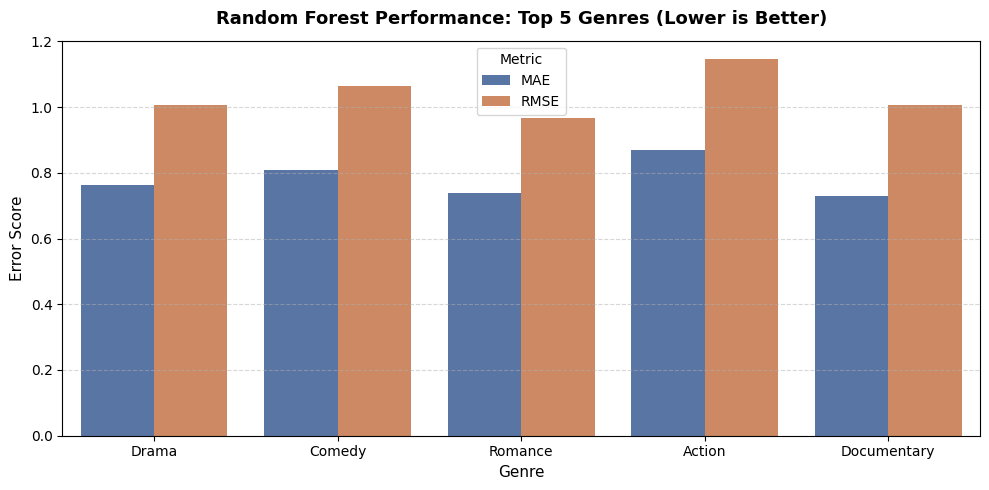


----------------------------------------
Analyzing Fairness by Language (English vs Foreign)
----------------------------------------

📊 LANGUAGE FAIRNESS METRICS TABLE (Random Forest):


,MAE,RMSE
Language,,
English,0.709965,0.941647
Foreign,0.843007,1.110718


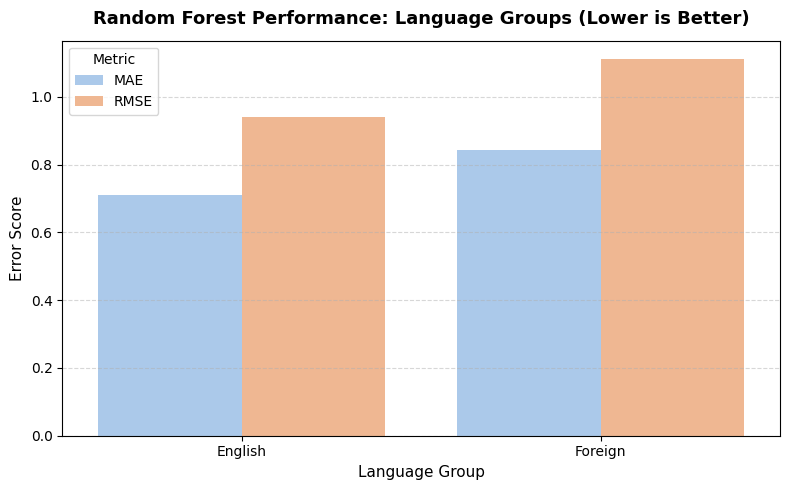

In [10]:


print("=== Running Fairness & Slice Analysis (Random Forest Only) ===")

# 1. הפקת הפיצ'רים על ה-Train וה-Test (באמצעות הצינור הרשמי והסטרילי עם 11 הז'אנרים)
final_mappings = {}
X_train_final = prepare_data(X_train_raw, crew_lookup_df, is_train=True, mappings=final_mappings)
X_test_final = prepare_data(X_test_raw, crew_lookup_df, is_train=False, mappings=final_mappings)

y_train_final = y_train_raw.values
y_test_final = y_test_raw.values

# 2. אימון מודל ה-Random Forest הסופי וביצוע חיזוי
print("Training Random Forest model...")
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train_final, y_train_final)
rf_preds = rf_model.predict(X_test_final)

# 3. יצירת בסיס נתונים לניתוח על גבי ה-Test set המקורי
fairness_df = X_test_raw.copy()
fairness_df['Actual'] = y_test_final
fairness_df['RF_Pred'] = rf_preds

# =====================================================================
# חלק א': ניתוח לפי 5 הז'אנרים הנפוצים ביותר
# =====================================================================
print("\n" + "-"*40 + "\nAnalyzing Fairness by Top 5 Genres\n" + "-"*40)

# שליפת 5 הז'אנרים המובילים מתוך המילון שנלמד ב-Train
top_5_genres = final_mappings.get('genre', {}).get('top_genres', [])[:5]

genre_results = []

for genre in top_5_genres:
    # סינון הסרטים שמכילים את הז'אנר הנוכחי (סרט יכול להופיע ביותר מז'אנר אחד)
    genre_mask = fairness_df['genres'].astype(str).str.contains(genre, case=False, na=False)
    sub_df = fairness_df[genre_mask]
    
    if not sub_df.empty:
        # חישוב מדדים ל-Random Forest
        rf_mae = mean_absolute_error(sub_df['Actual'], sub_df['RF_Pred'])
        rf_rmse = np.sqrt(mean_squared_error(sub_df['Actual'], sub_df['RF_Pred']))
        
        genre_results.append({'Genre': genre, 'MAE': rf_mae, 'RMSE': rf_rmse})

df_genre_fairness = pd.DataFrame(genre_results)

# הצגת הטבלה המסודרת לז'אנרים
print("\n📊 GENRE FAIRNESS METRICS TABLE (Random Forest):")
display(df_genre_fairness.set_index('Genre')[['MAE', 'RMSE']])

# יצירת ה-Bar Chart לז'אנרים (הצגת MAE ו-RMSE זה לצד זה)
df_genre_melted = pd.melt(df_genre_fairness, id_vars=['Genre'], value_vars=['MAE', 'RMSE'], 
                          var_name='Metric', value_name='Error_Value')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_genre_melted, x='Genre', y='Error_Value', hue='Metric', palette='deep')
plt.title('Random Forest Performance: Top 5 Genres (Lower is Better)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Error Score', fontsize=11)
plt.xlabel('Genre', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# =====================================================================
# חלק ב': ניתוח לפי שפה (English vs Foreign)
# =====================================================================
print("\n" + "-"*40 + "\nAnalyzing Fairness by Language (English vs Foreign)\n" + "-"*40)

# חלוקת הסרטים לפי שפה המבוססת על המשתנה המקורי
fairness_df['Language_Group'] = fairness_df['Language'].astype(str).str.lower().apply(
    lambda x: 'English' if 'english' in x else 'Foreign'
)

lang_results = []

for group in ['English', 'Foreign']:
    sub_df = fairness_df[fairness_df['Language_Group'] == group]
    
    if not sub_df.empty:
        # חישוב מדדים ל-Random Forest
        rf_mae = mean_absolute_error(sub_df['Actual'], sub_df['RF_Pred'])
        rf_rmse = np.sqrt(mean_squared_error(sub_df['Actual'], sub_df['RF_Pred']))
        
        lang_results.append({'Language': group, 'MAE': rf_mae, 'RMSE': rf_rmse})

df_lang_fairness = pd.DataFrame(lang_results)

# הצגת הטבלה המסודרת לשפות
print("\n📊 LANGUAGE FAIRNESS METRICS TABLE (Random Forest):")
display(df_lang_fairness.set_index('Language')[['MAE', 'RMSE']])

# יצירת ה-Bar Chart לשפות (הצגת MAE ו-RMSE זה לצד זה)
df_lang_melted = pd.melt(df_lang_fairness, id_vars=['Language'], value_vars=['MAE', 'RMSE'], 
                         var_name='Metric', value_name='Error_Value')

plt.figure(figsize=(8, 5))
sns.barplot(data=df_lang_melted, x='Language', y='Error_Value', hue='Metric', palette='pastel')
plt.title('Random Forest Performance: Language Groups (Lower is Better)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Error Score', fontsize=11)
plt.xlabel('Language Group', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Feature Analysis

=== Running Top 5 Feature Importance & Coefficients Analysis ===

--------------------------------------------------
[1/2] Extracting Random Forest Feature Importance
--------------------------------------------------

🥇 RANDOM FOREST - TOP 5 FEATURES:


,Importance
Feature,
weighted_actor_reputation_10yrs,0.346002
genre_documentary,0.193323
weighted_director_reputation_10yrs,0.185728
genre_horror,0.134181
genre_drama,0.061181



--------------------------------------------------
[2/2] Extracting Elastic Net Standardized Coefficients
--------------------------------------------------

🥇 ELASTIC NET - TOP 5 FEATURES (By Absolute Impact):


,Coefficient,Abs_Coefficient
Feature,,
genre_documentary,1.253153,1.253153
genre_horror,-0.717768,0.717768
genre_drama,0.290941,0.290941
weighted_actor_reputation_10yrs,0.266436,0.266436
genre_action,-0.250158,0.250158


C:\Users\micha\AppData\Local\Temp\ipykernel_5212\977203639.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rf_top5, x='Importance', y='Feature', palette='viridis', ax=axes[0])
C:\Users\micha\AppData\Local\Temp\ipykernel_5212\977203639.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_en_top5, x='Coefficient', y='Feature', palette='coolwarm', ax=axes[1])


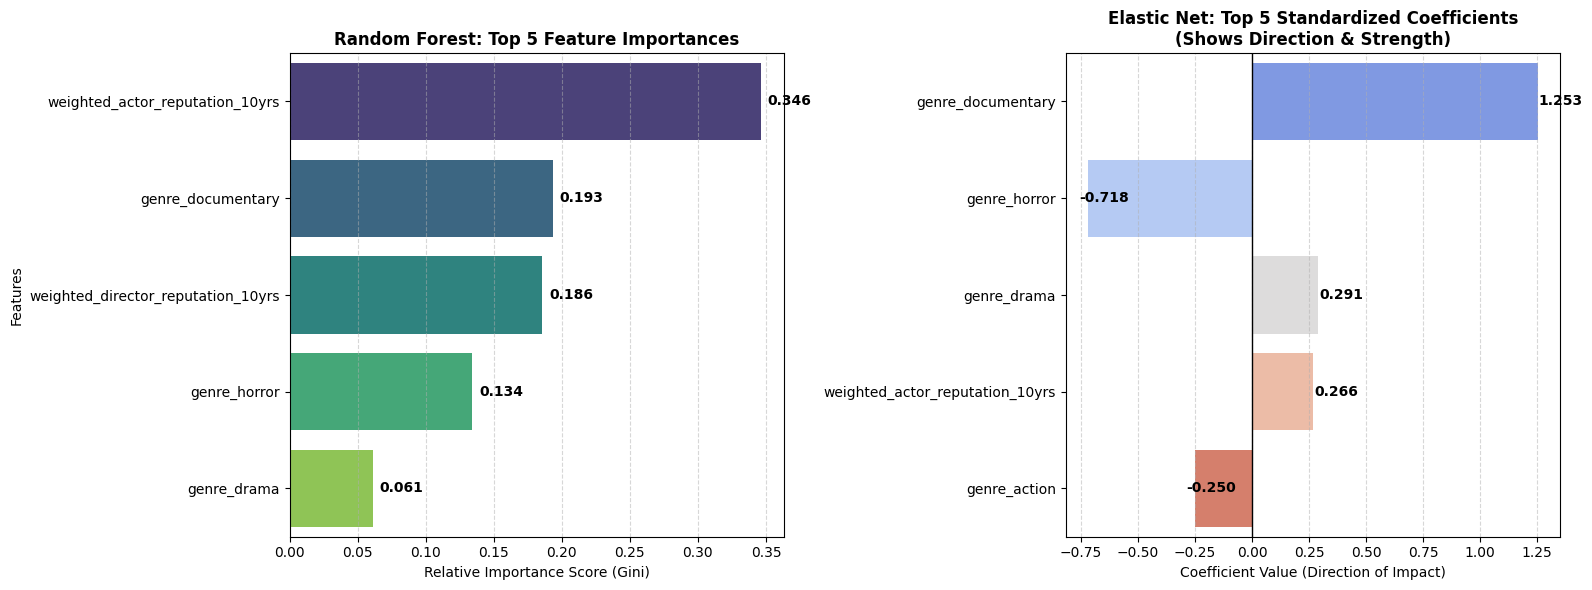

In [12]:


print("=== Running Top 5 Feature Importance & Coefficients Analysis ===")

# 1. הפקת הפיצ'רים על ה-Train וה-Test (באמצעות הצינור הרשמי והסטרילי עם 11 הז'אנרים)
final_mappings = {}
X_train_final = prepare_data(X_train_raw, crew_lookup_df, is_train=True, mappings=final_mappings)
X_test_final = prepare_data(X_test_raw, crew_lookup_df, is_train=False, mappings=final_mappings)

y_train_final = y_train_raw.values
feature_names = X_train_final.columns.tolist()

# =====================================================================
# חלק א': RANDOM FOREST - FEATURE IMPORTANCE
# =====================================================================
print("\n" + "-"*50 + "\n[1/2] Extracting Random Forest Feature Importance\n" + "-"*50)

rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train_final, y_train_final)

# שליפת החשיבויות ויצירת DataFrame מסודר וממוין
df_rf_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# חיתוך 5 המובילים בלבד
df_rf_top5 = df_rf_imp.head(5)

print("\n🥇 RANDOM FOREST - TOP 5 FEATURES:")
display(df_rf_top5.set_index('Feature'))


# =====================================================================
# חלק ב': ELASTIC NET - STANDARDIZED COEFFICIENTS
# =====================================================================
print("\n" + "-"*50 + "\n[2/2] Extracting Elastic Net Standardized Coefficients\n" + "-"*50)

# נרמול הפיצ'רים הרציפים (חובה עבור מקדמים סטנדרטיים במודל ליניארי!)
continuous_cols = ['weighted_actor_reputation_10yrs', 'weighted_director_reputation_10yrs']
scaler = StandardScaler()
X_train_scaled = X_train_final.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train_final[continuous_cols])

en_model = ElasticNet(alpha=0.001, l1_ratio=0.3, random_state=42, max_iter=2000)
en_model.fit(X_train_scaled, y_train_final)

# שליפת המקדמים, חישוב ערך מוחלט ומיון לפי עוצמת ההשפעה
df_en_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': en_model.coef_,
    'Abs_Coefficient': np.abs(en_model.coef_)
}).sort_values(by='Abs_Coefficient', ascending=False)

# חיתוך 5 המובילים בלבד
df_en_top5 = df_en_coef.head(5)

print("\n🥇 ELASTIC NET - TOP 5 FEATURES (By Absolute Impact):")
display(df_en_top5.set_index('Feature')[['Coefficient', 'Abs_Coefficient']])


# =====================================================================
# חלק ג': ויזואליזציה מקצועית - שני גרפים נפרדים זה לצד זה
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. גרף שמאל: Random Forest
sns.barplot(data=df_rf_top5, x='Importance', y='Feature', palette='viridis', ax=axes[0])
axes[0].set_title('Random Forest: Top 5 Feature Importances', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Relative Importance Score (Gini)')
axes[0].set_ylabel('Features')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# הוספת ערך מספרי על גבי הברים של ה-RF
for index, value in enumerate(df_rf_top5['Importance']):
    axes[0].text(value + 0.005, index, f'{value:.3f}', va='center', fontsize=10, fontweight='semibold')

# 2. גרף ימין: Elastic Net (מציג את המקדם המקורי כולל כיוון ההשפעה - חיובי או שלילי)
# אנחנו ממיינים אותו לפי הערך המוחלט אבל מציגים את ה-Coefficient האמיתי
sns.barplot(data=df_en_top5, x='Coefficient', y='Feature', palette='coolwarm', ax=axes[1])
axes[1].set_title('Elastic Net: Top 5 Standardized Coefficients\n(Shows Direction & Strength)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coefficient Value (Direction of Impact)')
axes[1].set_ylabel('')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1) # קו אפס להדגשת חיובי/שלילי
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

# הוספת ערך מספרי על גבי הברים של ה-EN
for index, value in enumerate(df_en_top5['Coefficient']):
    offset = 0.005 if value >= 0 else -0.04
    axes[1].text(value + offset, index, f'{value:.3f}', va='center', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()

Saving pkl best model

In [13]:
import joblib

model_filename = 'best_movie_rating_model.pkl'

# 2. ניצור מילון שמחזיק גם את המודל המאומן וגם את המיפויים שנוצרו ב-Train
artifacts_to_save = {
    'model': rf_model,             
    'mappings': trained_mappings   
}

# 3. שמירת האובייקט לקובץ pkl
joblib.dump(artifacts_to_save, model_filename)

print(f"🥇 המודל והמיפויים נשמרו בהצלחה בקובץ: {model_filename}")

🥇 המודל והמיפויים נשמרו בהצלחה בקובץ: best_movie_rating_model.pkl
